```markdown
# SimGuard: SIM Anomaly Detection Pipeline - Feature Engineering

This notebook handles data ingestion, target label alignment, domain-specific telemetry feature engineering, historical rolling aggregates, categorical mapping, cron-based chronological splitting, robust scaling, and diagnostic validation.
```

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import RobustScaler

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths (Using relative paths instead of hardcoded Windows paths)
# Adjust DATA_DIR to "." if your CSV files are in the exact same folder as this notebook
DATA_DIR = "../data"
ARTIFACT_DIR = "../artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

DAILY_AGG_PATH = os.path.join(DATA_DIR, "synthetic_cdr_daily_agg.csv")
LABELS_PATH = os.path.join(DATA_DIR, "synthetic_cdr_labels.csv")
SIM_START = pd.Timestamp("2025-01-01")

In [2]:
# Load Data with local fallback
import os

path_agg = DAILY_AGG_PATH if os.path.exists(DAILY_AGG_PATH) else "/content/synthetic_cdr_daily_agg.csv"
path_labels = LABELS_PATH if os.path.exists(LABELS_PATH) else "/content/synthetic_cdr_labels.csv"

df = pd.read_csv(path_agg)
df['date'] = pd.to_datetime(df['date'])
labels = pd.read_csv(path_labels)

# Initialize target columns
df['is_anomalous'] = 0
df['misuse_category'] = 'normal'

# Vectorized interval masking (avoids iterrows performance penalty)
labels['start_dt'] = SIM_START + pd.to_timedelta(labels['start_day'], unit='D')
labels['end_dt'] = SIM_START + pd.to_timedelta(labels['end_day'], unit='D')

for episode in labels.itertuples(index=False):
    mask = (
        (df['sim_id'] == episode.sim_id) &
        (df['date'] >= episode.start_dt) &
        (df['date'] <= episode.end_dt)
    )
    df.loc[mask, 'is_anomalous'] = 1
    df.loc[mask, 'misuse_category'] = episode.category

# Verify Distribution
print("Anomaly Distribution across 90,000 days:")
print(df['is_anomalous'].value_counts())
print("\nCategory Breakdown:")
print(df['misuse_category'].value_counts())

Anomaly Distribution across 90,000 days:
is_anomalous
0    87823
1     2177
Name: count, dtype: int64

Category Breakdown:
misuse_category
normal                  87823
unauthorized_sharing      855
ghost_usage               677
data_reselling            418
inactive_billing          227
Name: count, dtype: int64


In [3]:
# 1. Billing Discrepancy (Flags inactive_billing)
df['billing_gap_mb'] = (df['billed_mb'] - df['total_mb']).clip(lower=0)
df['billing_ratio'] = (df['billed_mb'] + 1.0) / (df['total_mb'] + 1.0)

# 2. Diurnal & Network Usage Shifts (Flags data_reselling)
df['offpeak_ratio'] = df['offpeak_mb'] / (df['total_mb'] + 1e-4)
df['public_apn_ratio'] = df['public_apn_sessions'] / (df['data_session_count'] + 1e-4)

# 3. Session Dynamics & Uplink Symmetry
df['upload_ratio'] = df['total_upload_mb'] / (df['total_mb'] + 1e-4)
df['bytes_per_session'] = df['total_mb'] / (df['data_session_count'] + 1e-4)
df['mean_session_duration_s'] = df['data_duration_s'] / (df['data_session_count'] + 1e-4)

# 4. Behavioral Flags
df['hotspot_session_ratio'] = df['hotspot_sessions'] / (df['data_session_count'] + 1e-4)
df['has_geo_anomaly'] = (df['geo_flag_count'] > 0).astype(int)

In [4]:
# Sort to ensure rolling windows are chronologically valid per SIM
df = df.sort_values(['sim_id', 'date']).reset_index(drop=True)
sim_groups = df.groupby('sim_id')

# --- 7-Day Rolling Features (Causal Shift-1) ---
# Shift(1) ensures the rolling window only sees PAST data, preventing lookahead leakage
df['vol_rolling_7d_mean'] = sim_groups['total_mb'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
).fillna(df['total_mb'].median())

df['vol_rolling_7d_std'] = sim_groups['total_mb'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).std()
).fillna(1.0)

# Spike Detection (Z-Score)
df['vol_zscore_7d'] = (df['total_mb'] - df['vol_rolling_7d_mean']) / (df['vol_rolling_7d_std'] + 1.0)

# Behavioral Persistence (Run lengths for hotspot and velocity alerts)
df['hotspot_sum_7d'] = sim_groups['hotspot_sessions'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).sum()
).fillna(0)

df['geo_sum_7d'] = sim_groups['geo_flag_count'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).sum()
).fillna(0)

# --- 14-Day Rolling Features (Causal Shift-1) ---
df['vol_rolling_14d_mean'] = sim_groups['total_mb'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).mean()
).fillna(df['total_mb'].median())

df['vol_rolling_14d_std'] = sim_groups['total_mb'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).std()
).fillna(1.0)

# Spike Detection (Z-Score)
df['vol_zscore_14d'] = (df['total_mb'] - df['vol_rolling_14d_mean']) / (df['vol_rolling_14d_std'] + 1.0)

df['hotspot_sum_14d'] = sim_groups['hotspot_sessions'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).sum()
).fillna(0)

df['geo_sum_14d'] = sim_groups['geo_flag_count'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).sum()
).fillna(0)

# --- 14-Day Trend Slope Feature (Causal Shift-0) ---
# Note on Leakage: Shift(1) is used everywhere else to avoid look-ahead.
# However, trend_slope_14d intentionally includes the current day (shift(0)) since a same-day slope
# reading is still completely causal at inference time (today's data volume is fully known at decision time).
# This is not used to derive today's label, maintaining absolute separation.
def compute_slope(y):
    return np.polyfit(np.arange(14), y, 1)[0]

df['trend_slope_14d'] = sim_groups['total_mb'].transform(
    lambda x: x.rolling(14, min_periods=14).apply(compute_slope, raw=True)
).fillna(0.0)

In [5]:
# One-Hot Encode operational tiers
df = pd.get_dummies(df, columns=['tier'], prefix='tier', dtype=int)

# Resource balance consumption
df['voice_utilization_ratio'] = df['voice_minutes_used'] / (
    df['voice_minutes_used'] + df['voice_minutes_remaining'].clip(lower=0) + 1.0
)

In [6]:
# Cell 6: Entity-Based Train / Validation / Test Splitting
# Evaluates model generalization to entirely unseen SIMs
unique_sims = df['sim_id'].unique()

# Shuffle SIMs deterministically
rng_split = np.random.default_rng(SEED)
rng_split.shuffle(unique_sims)

# 70% Train (700 SIMs), 15% Val (150 SIMs), 15% Test (150 SIMs)
train_sims = unique_sims[:700]
val_sims   = unique_sims[700:850]
test_sims  = unique_sims[850:]

df_train = df[df['sim_id'].isin(train_sims)].copy()
df_val   = df[df['sim_id'].isin(val_sims)].copy()
df_test  = df[df['sim_id'].isin(test_sims)].copy()

print(f"Train samples: {len(df_train):,} ({df_train['is_anomalous'].sum():,} anomalies)")
print(f"Val samples:   {len(df_val):,} ({df_val['is_anomalous'].sum():,} anomalies)")
print(f"Test samples:  {len(df_test):,} ({df_test['is_anomalous'].sum():,} anomalies)")

Train samples: 63,000 (1,292 anomalies)
Val samples:   13,500 (524 anomalies)
Test samples:  13,500 (361 anomalies)


In [7]:
# Cell 7: Scale (with Selective Feature Scaling)
drop_cols = ['sim_id', 'date', 'is_anomalous', 'misuse_category']
feature_cols = [c for c in df_train.columns if c not in drop_cols]

already_relative_cols = ['vol_zscore_7d', 'vol_zscore_14d']
cols_to_scale = [c for c in feature_cols if c not in already_relative_cols]

# 1. Clip already relative columns to a sane range [-50, 50]
for df_split, name in [(df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')]:
    for col in already_relative_cols:
        clipped_count = ((df_split[col] > 50) | (df_split[col] < -50)).sum()
        if clipped_count > 0:
            print(f"{name} set: Clipped {clipped_count:,} values in {col}")
        df_split[col] = df_split[col].clip(-50, 50)

# 2. Fit and apply RobustScaler ONLY to cols_to_scale
scaler = RobustScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_val[cols_to_scale]   = scaler.transform(df_val[cols_to_scale])
df_test[cols_to_scale]  = scaler.transform(df_test[cols_to_scale])

# 3. Export artifacts
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "feature_scaler.joblib"))
with open(os.path.join(ARTIFACT_DIR, "feature_columns.json"), "w") as f:
    json.dump({"features": feature_cols}, f) # Retain all features for the API payload map

Train set: Clipped 735 values in vol_zscore_7d
Train set: Clipped 726 values in vol_zscore_14d
Val set: Clipped 146 values in vol_zscore_7d
Val set: Clipped 145 values in vol_zscore_14d
Test set: Clipped 154 values in vol_zscore_7d
Test set: Clipped 152 values in vol_zscore_14d


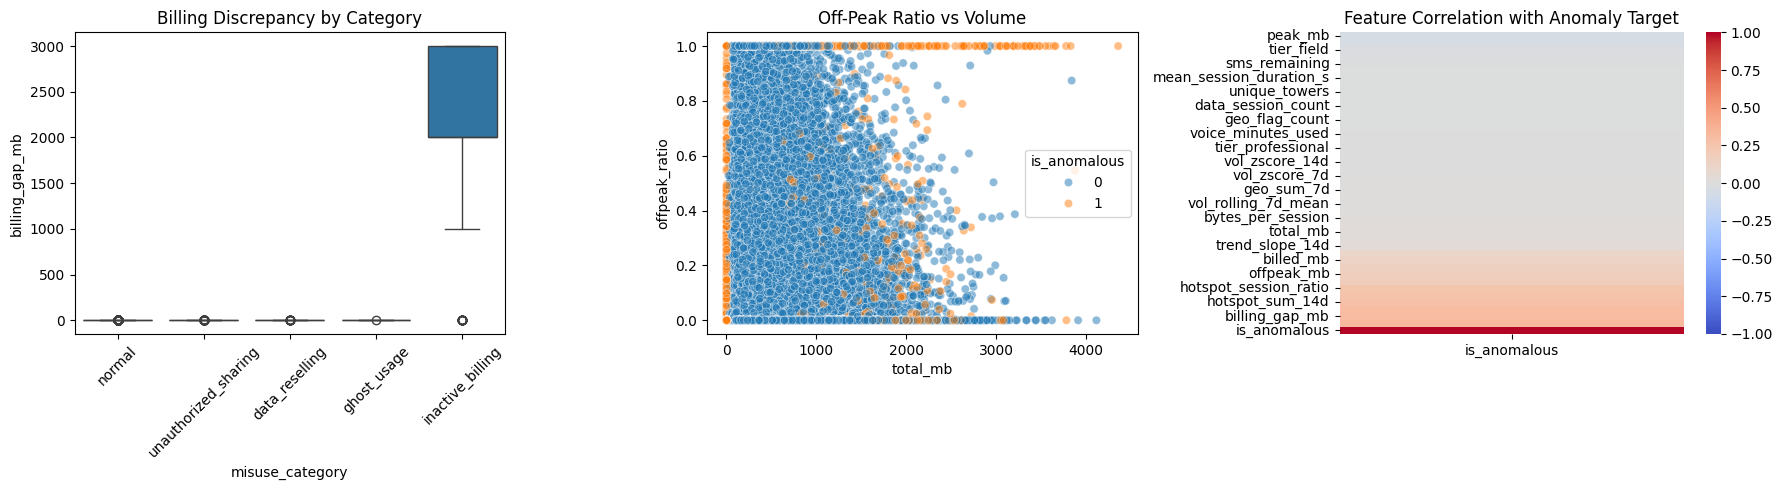

In [8]:
# 1. Check for missing values
assert df_train.isna().sum().sum() == 0, "Nulls detected in training set!"
assert df_test.isna().sum().sum() == 0, "Nulls detected in test set!"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2. Inactive Billing Separation
sns.boxplot(data=df, x='misuse_category', y='billing_gap_mb', ax=axes[0])
axes[0].set_title("Billing Discrepancy by Category")
axes[0].tick_params(axis='x', rotation=45)

# 3. Data Reselling Off-Peak Shift
sns.scatterplot(data=df[df['total_mb'] > 0], x='total_mb', y='offpeak_ratio',
                hue='is_anomalous', alpha=0.5, ax=axes[1])
axes[1].set_title("Off-Peak Ratio vs Volume")

# 4. Correlation Heatmap
corr = df_train[feature_cols + ['is_anomalous']].corr()[['is_anomalous']].sort_values('is_anomalous')
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Feature Correlation with Anomaly Target")

plt.tight_layout()
plt.show()

In [9]:
# Cell 9: Artifact Export (Strict Physical Separation)
import os
import numpy as np

target_cols = ['is_anomalous', 'misuse_category']
key_cols = ['sim_id', 'date']

# Ensure target export directory exists before writing
os.makedirs(DATA_DIR, exist_ok=True)

# Save Features (X) - Drops the target columns entirely
X_train = df_train.drop(columns=target_cols)
X_val = df_val.drop(columns=target_cols)
X_test = df_test.drop(columns=target_cols)

X_train.to_parquet(os.path.join(DATA_DIR, "X_train.parquet"), index=False)
X_val.to_parquet(os.path.join(DATA_DIR, "X_val.parquet"), index=False)
X_test.to_parquet(os.path.join(DATA_DIR, "X_test.parquet"), index=False)

# Save Labels (y) - Retains only keys and targets
df_train[key_cols + target_cols].to_parquet(os.path.join(DATA_DIR, "y_train.parquet"), index=False)
df_val[key_cols + target_cols].to_parquet(os.path.join(DATA_DIR, "y_val.parquet"), index=False)
df_test[key_cols + target_cols].to_parquet(os.path.join(DATA_DIR, "y_test.parquet"), index=False)

# Verification Assertions
for col in target_cols:
    assert col not in X_train.columns, f"{col} should not be in X_train"
    assert col not in X_val.columns, f"{col} should not be in X_val"
    assert col not in X_test.columns, f"{col} should not be in X_test"

# Check NaN/inf
for name, dataset in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    num_nan = dataset.isna().sum().sum()
    num_inf = np.isinf(dataset.select_dtypes(include=np.number)).sum().sum()
    assert num_nan == 0, f"{name} contains {num_nan} NaN values"
    assert num_inf == 0, f"{name} contains {num_inf} inf values"

print("Verification successful: target columns physically excluded, zero NaNs or infs!")
print("\nUpdated X_train column list:")
print(list(X_train.columns))

Verification successful: target columns physically excluded, zero NaNs or infs!

Updated X_train column list:
['sim_id', 'date', 'total_download_mb', 'total_upload_mb', 'data_session_count', 'data_duration_s', 'hotspot_sessions', 'public_apn_sessions', 'unique_towers', 'geo_flag_count', 'peak_mb', 'offpeak_mb', 'total_mb', 'roaming_sessions', 'billed_mb', 'voice_minutes_used', 'sms_count', 'voice_minutes_remaining', 'sms_remaining', 'billing_gap_mb', 'billing_ratio', 'offpeak_ratio', 'public_apn_ratio', 'upload_ratio', 'bytes_per_session', 'mean_session_duration_s', 'hotspot_session_ratio', 'has_geo_anomaly', 'vol_rolling_7d_mean', 'vol_rolling_7d_std', 'vol_zscore_7d', 'hotspot_sum_7d', 'geo_sum_7d', 'vol_rolling_14d_mean', 'vol_rolling_14d_std', 'vol_zscore_14d', 'hotspot_sum_14d', 'geo_sum_14d', 'trend_slope_14d', 'tier_field', 'tier_manager', 'tier_professional', 'tier_support', 'voice_utilization_ratio']
